# CUSTOMER CHURN PREDICTION USING MACHINE LEARNING
---
## Business Problem:
Customer churn is one of the biggest challenges for
subscription-based businesses.

The objective of this project is to predict whether a
customer is likely to leave the company and identify
the key factors driving churn.

## Business Benefits:
- Improve customer retention
- Reduce revenue loss
- Enable targeted retention campaigns
- Support business decision-making

Author: Subhankar Mondal

## Data Information

- customerID: A unique identifier for each customer.
- gender: The gender of the customer (Male/Female).
- SeniorCitizen: Indicates if the customer is a senior citizen (1 = Yes, 0 = No).
- Partner: Indicates if the customer has a partner (Yes/No).
- Dependents: Indicates if the customer has dependents (Yes/No).
- tenure: Number of months the customer has stayed with the company.
- PhoneService: Indicates if the customer has a phone service (Yes/No).
- MultipleLines: Indicates if the customer has multiple lines (Yes/No/No phone service).
- InternetService: Type of internet service (DSL, Fiber optic, None).
- OnlineSecurity: Indicates if the customer has online security add-ons (Yes/No/No internet service).
- DeviceProtection: Indicates if the customer has device protection add-ons (Yes/No/No internet service).
- TechSupport: Indicates if the customer has tech support add-ons (Yes/No/No internet service).
- StreamingTV: Indicates if the customer streams TV services (Yes/No/No internet service).
- StreamingMovies: Indicates if the customer streams movies (Yes/No/No internet service).
- Contract: Type of contract (Month-to-month, One year, Two year).
- PaperlessBilling: Indicates if the customer uses paperless billing (Yes/No).
- PaymentMethod: The payment method used (e.g., Electronic check, Mailed check, Bank transfer, Credit card).
- MonthlyCharges: Monthly charges for the customer.
- TotalCharges: Total charges billed to the customer.
- Churn: Indicates if the customer has churned (Yes/No).

---
## STEP 1: ENVIRONMENT SETUP & DEPENDENCIES

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve
)

# Configuration settings for clean outputs and visualization
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Environment configured successfully. Dependencies loaded.")

Environment configured successfully. Dependencies loaded.


## STEP 2: DATA INGESTION & DATA INTEGRITY AUDITING

In [2]:
# Load dataset
df = pd.read_csv(r'D:\Data Analytics Project\customer_churn.csv')

In [3]:
# Preview the first few rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check the scale of the dataset
print("--- 1. Structural Dimensions ---")
print(f"Total Records: {df.shape[0]} | Total Features: {df.shape[1]}")

--- 1. Structural Dimensions ---
Total Records: 7043 | Total Features: 21


In [5]:
# Check data types and identify missing values structurally
print("--- 2. Data Type ---")
print(df.info())

--- 2. Data Type ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [6]:
# Generate a statistical summary of the numerical data
print("--- Statistical Summary ---")
df.describe()

--- Statistical Summary ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
# Check for missing values
print("\n--- 3. Missing Value Distribution ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No structural NaN values detected.")


--- 3. Missing Value Distribution ---
TotalCharges    11
dtype: int64


In [8]:
# Filling missing values
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    # Impute missing records with the column median to protect data integrity
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [9]:
# Check for Duplicate values
print("\n--- 4. Duplicate Row Assessment ---")
duplicate_count = df.duplicated().sum()
print(f"Identical duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("--> Duplicate records successfully deleted from the dataframe.")


--- 4. Duplicate Row Assessment ---
Identical duplicate rows found: 0


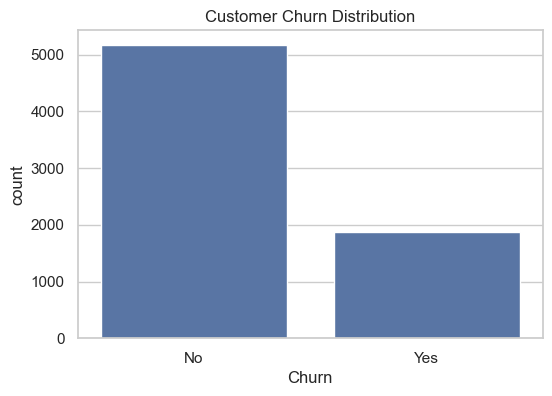

In [10]:
# Target Variable Analysis

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

## STEP 3: OUTLIER PROFILING VIA HISTOGRAMS & BOXPLOTS

In [11]:
# Identify continuous features for distribution analysis
continuous_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SeniorCitizen' in continuous_features:
    continuous_features.remove('SeniorCitizen')

print(f"Evaluating continuous distributions for outliers: {continuous_features}")

Evaluating continuous distributions for outliers: ['tenure', 'MonthlyCharges', 'TotalCharges']


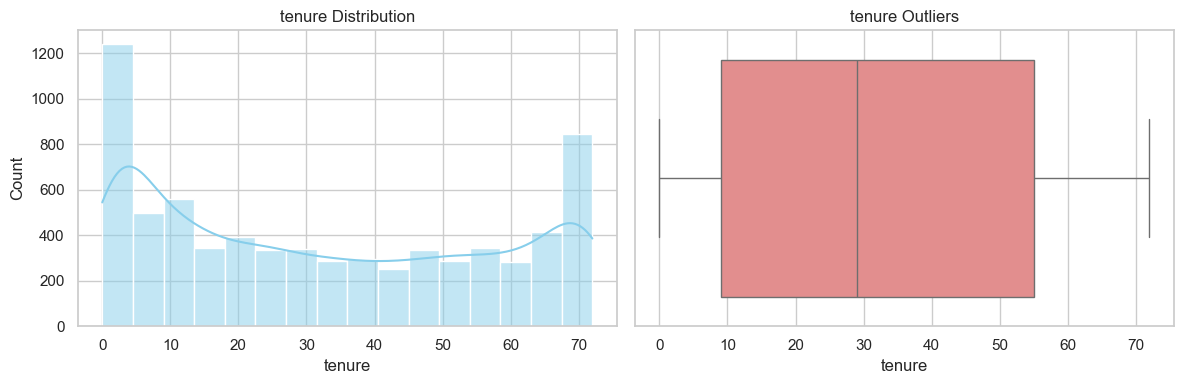

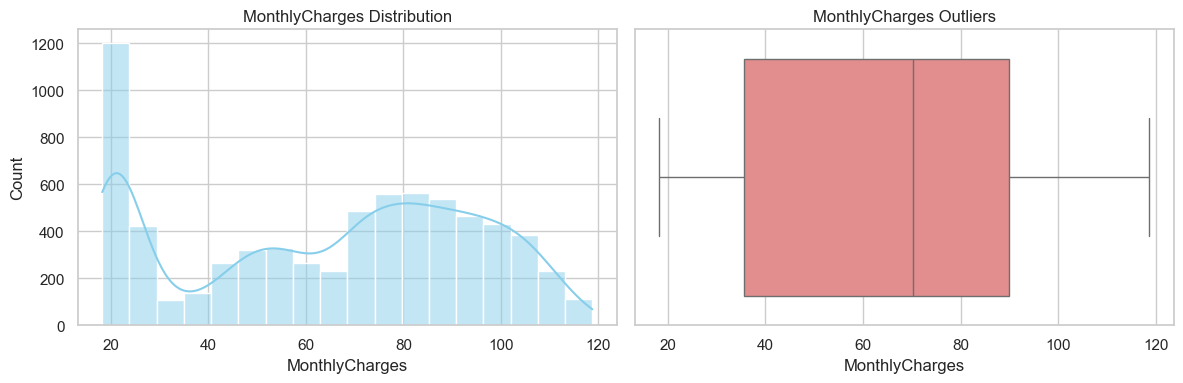

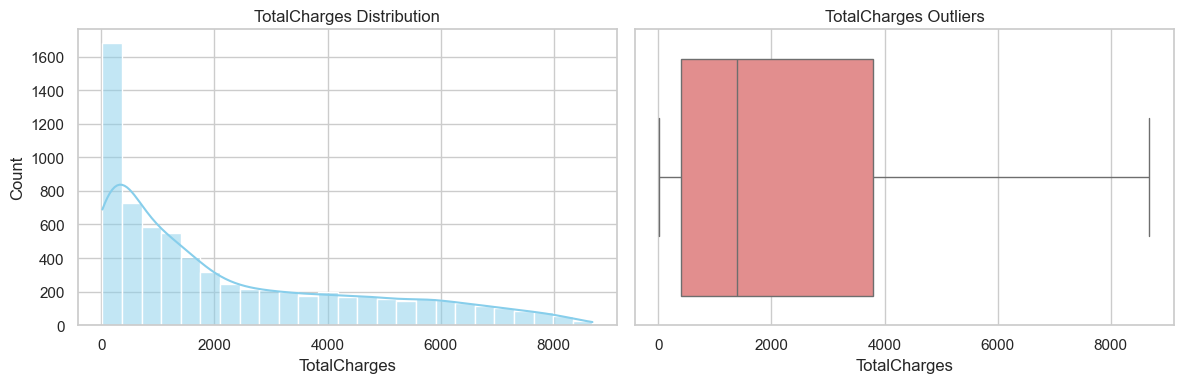

In [12]:
# Loop through each numeric column
for col in continuous_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: histogram with density curve
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')

    # Right: boxplot for outliers
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')

    plt.tight_layout()
    plt.show()

## STEP 4: CATEGORICAL DATA ENCODING

In [13]:
# Drop primary unique key records to remove architectural noise
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)


In [14]:
# Label Encoding
le = LabelEncoder()

for i in df.columns:
  if df[i].dtype == 'object':
    df[i]=le.fit_transform(df[i])
    print(f"column:{i}")
    print('original---> Encoder')
    for original_class,encoded_value in zip(le.classes_,le.transform(le.classes_)):
      print(f"{original_class}--->{encoded_value}")
    print()

column:gender
original---> Encoder
Female--->0
Male--->1

column:Partner
original---> Encoder
No--->0
Yes--->1

column:Dependents
original---> Encoder
No--->0
Yes--->1

column:PhoneService
original---> Encoder
No--->0
Yes--->1

column:MultipleLines
original---> Encoder
No--->0
No phone service--->1
Yes--->2

column:InternetService
original---> Encoder
DSL--->0
Fiber optic--->1
No--->2

column:OnlineSecurity
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:OnlineBackup
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:DeviceProtection
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:TechSupport
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:StreamingTV
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:StreamingMovies
original---> Encoder
No--->0
No internet service--->1
Yes--->2

column:Contract
original---> Encoder
Month-to-month--->0
One year--->1
Two year--->2

column:Paperle

## STEP 5: TRAIN-TEST SPLIT (Preventing Data Leakage)

In [15]:
# Segregate data space boundaries
X = df.drop(columns=['Churn'])
y = df['Churn']

In [16]:
# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=23, stratify=y
)

# Pick numeric columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Standardize numerical features using training statistics only
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5634, 19)
Testing shape: (1409, 19)


In [17]:
#Checking standardize dataset
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
395,0,0,0,0,1.370662,1,2,0,2,2,2,2,2,2,2,1,1,0.840837,1.627199
527,1,0,1,1,1.045329,1,2,1,0,2,0,2,2,0,1,1,1,0.995626,1.390723
2589,1,1,0,0,-1.191336,1,2,1,0,0,0,0,0,0,0,1,2,0.374804,-0.904525
3945,0,0,0,0,-1.191336,0,1,0,2,0,0,2,0,0,0,0,3,-1.016638,-0.945343
2370,1,0,1,0,1.492662,1,2,1,2,2,2,2,2,2,2,1,0,1.589818,2.439833


## STEP 6: MODEL BUILDING & HYPERPARAMETER TUNING

In [18]:
# Define estimator
base_model = RandomForestClassifier(random_state=23)

# Establish search matrix parameters
param_grid = {
    'n_estimators': [100, 150, 200],
    'criterion':['gini','entropy'],
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [2, 4, 5],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
    }

In [23]:
#Initializing grid search
print("--- Initializing Grid Search ---")
grid_search = GridSearchCV(
    estimator=base_model, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', # Focus evaluation metrics on optimizing recall matrix weights
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"\nOptimal Parameter Extracted: {grid_search.best_params_}")

--- Initializing Grid Search ---
Fitting 3 folds for each of 432 candidates, totalling 1296 fits

Optimal Parameter Extracted: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}


## STEP 7: EVALUATION & PERFORMANCE METRICS

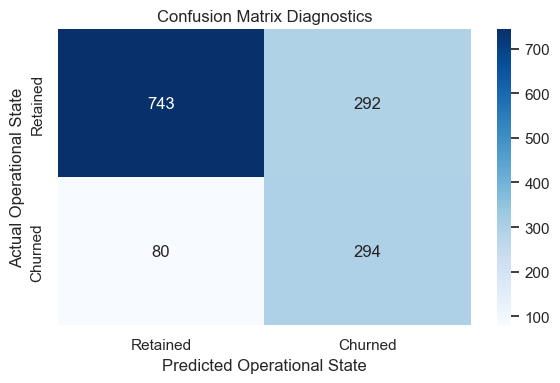

In [21]:
# Render confusion matrix heatmap graphic
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix Diagnostics')
plt.xlabel('Predicted Operational State')
plt.ylabel('Actual Operational State')
plt.tight_layout()
plt.show()

## STEP 8: FEATURE IMPORTANCE EXTRACTION

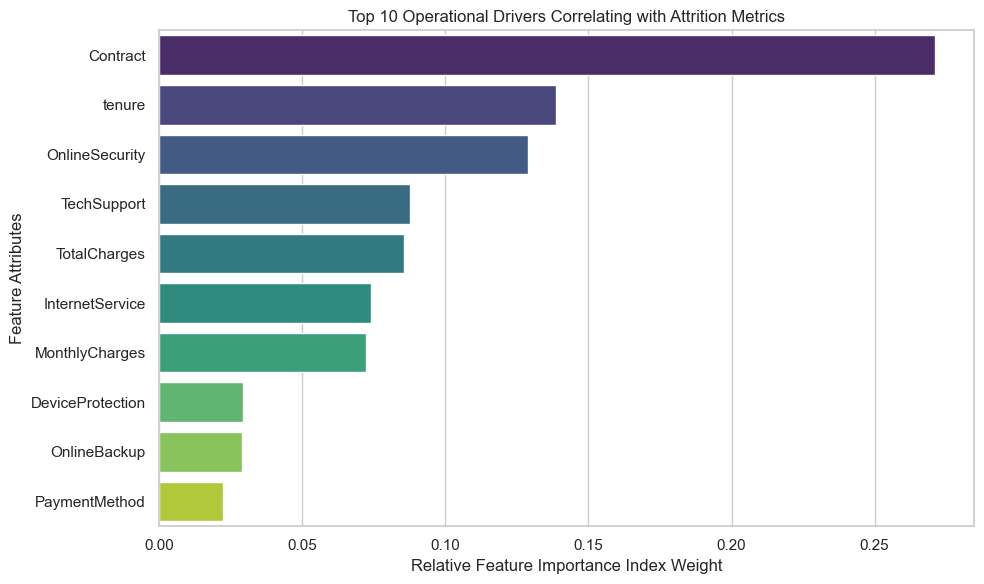


--- Top Root Drivers of Customer Churn ---
       Feature  Importance
      Contract    0.271137
        tenure    0.138679
OnlineSecurity    0.128907
   TechSupport    0.087812
  TotalCharges    0.085708


In [22]:
# Isolate internal node split frequencies to track feature importances
importances = best_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize primary feature weights
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Operational Drivers Correlating with Attrition Metrics')
plt.xlabel('Relative Feature Importance Index Weight')
plt.ylabel('Feature Attributes')
plt.tight_layout()
plt.show()

print("\n--- Top Root Drivers of Customer Churn ---")
print(feature_imp_df.head(5).to_string(index=False))

---
# Business Conclusion

### BUSINESS INSIGHTS

1. Customers with shorter tenure show higher churn.

2. Monthly charges significantly influence churn.

3. Contract type impacts retention.

4. Electronic payment customers have
   higher churn probability.

### RECOMMENDATIONS

- Offer loyalty discounts.
- Promote annual contracts.
- Launch targeted retention campaigns.
- Focus on high-risk customer segments.